# WideResNet101 Benchmark

In [1]:
model_name = "WideResNet101"

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def compile_str(mlir):
    return iree.runtime.load_vm_flatbuffer(
        iree.compiler.compile_str(
            mlir, input_type="tosa", target_backends=["llvm-cpu"],
            extra_args=[
                "--iree-llvmcpu-target-cpu-features=host",
                "--iree-stream-partitioning-favor=max-concurrency",
                "--iree-flow-zero-fill-empty-tensors",
                "--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0",
                "--iree-opt-const-eval",
                "--iree-opt-const-expr-hoisting",
                "--iree-opt-numeric-precision-reduction",
                "--iree-opt-strip-assertions"
            ]
        ),
        backend="llvm-cpu"
    )

def compile_file(filename):
    with open(filename) as f:
        return compile_str(f.read())
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [2]:
model = tf.function(tf.saved_model.load("model").signatures["serving_default"])

recompute, storeall = [
    compile_file(x) for x in ["../recompute.mlir", "../storeall.mlir"]
]

2023-07-14 17:51:07.436744: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Experimental

In [3]:
image = tf.random.normal((1, 3, 224, 224))

with tf.GradientTape(persistent=True) as tape:
    tape.watch(image)
    output = list(model(image).values()).pop()
    
grad = tf.random.normal((1, 1000))

image_np = image.numpy()
grad_np = grad.numpy()

df = pd.DataFrame()

### TensorFlow (Baseline)

In [4]:
baseline_f = timeit("model(image)")
baseline_b = timeit("tape.gradient(output, image, grad)")
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "TensorFlow")])

### Nabla without Optim

In [5]:
f = timeit("recompute.forward(image_np)")
b = timeit("recompute.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla")])

### Nabla with Optim

In [6]:
f = timeit("storeall.forward(image_np)")
b = timeit("storeall.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla Optim")])

## Result

In [7]:
df.to_csv(f"{model_name}-time.csv")
df.style.hide(axis="index")

time,pass,item
186.554303,Forward,TensorFlow
470.569093,Backward,TensorFlow
657.123396,Full,TensorFlow
215.833834,Forward,Nabla
814.515194,Backward,Nabla
1030.349029,Full,Nabla
238.583135,Forward,Nabla Optim
442.369163,Backward,Nabla Optim
680.952298,Full,Nabla Optim


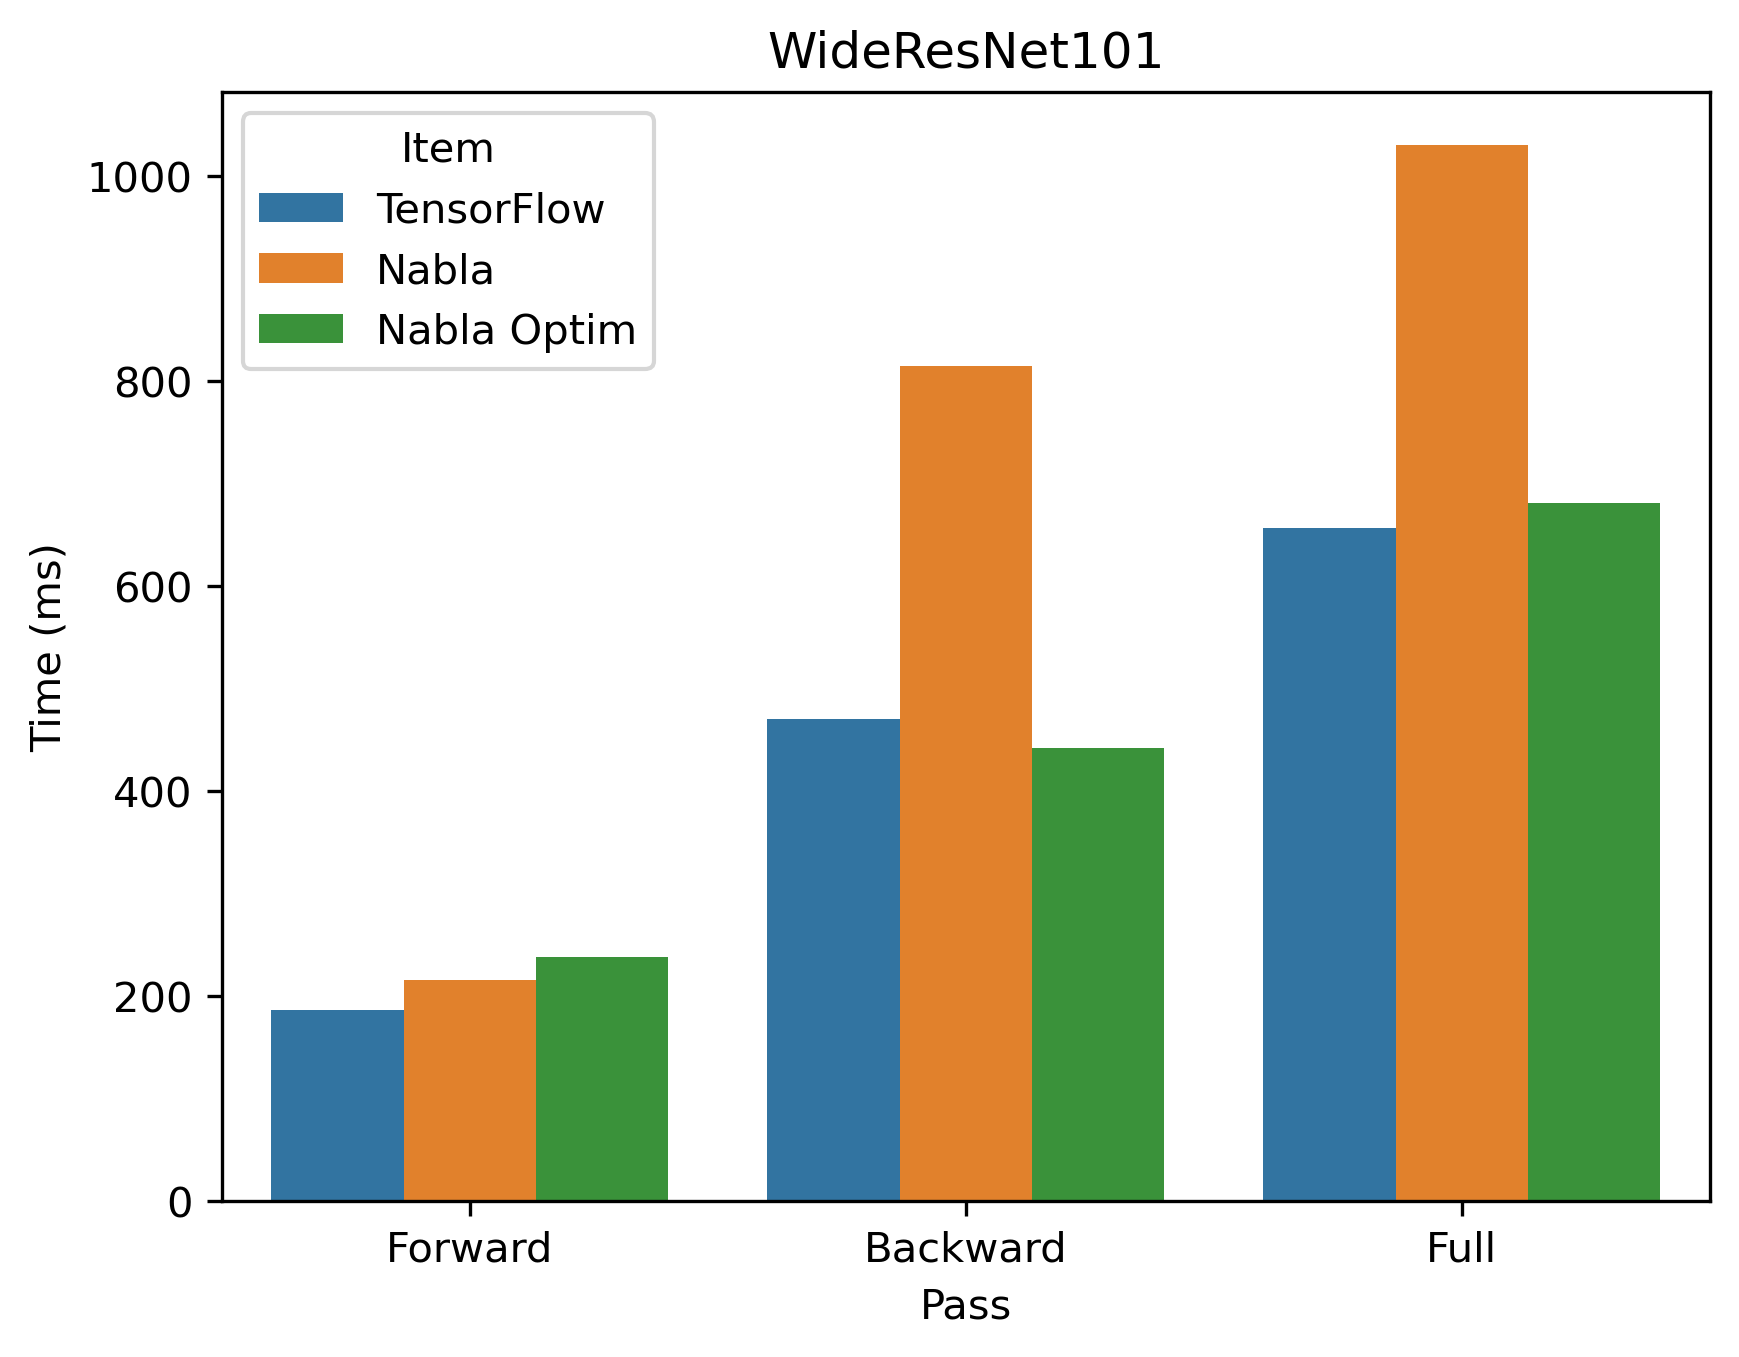

In [8]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [9]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,186.554303,Forward,TensorFlow,1.000000
0,215.833834,Forward,Nabla,0.864342
0,238.583135,Forward,Nabla Optim,0.781926


In [10]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,470.569093,Backward,TensorFlow,1.000000
0,814.515194,Backward,Nabla,0.577729
0,442.369163,Backward,Nabla Optim,1.063748


In [11]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,657.123396,Full,TensorFlow,1.000000
0,1030.349029,Full,Nabla,0.637768
0,680.952298,Full,Nabla Optim,0.965007


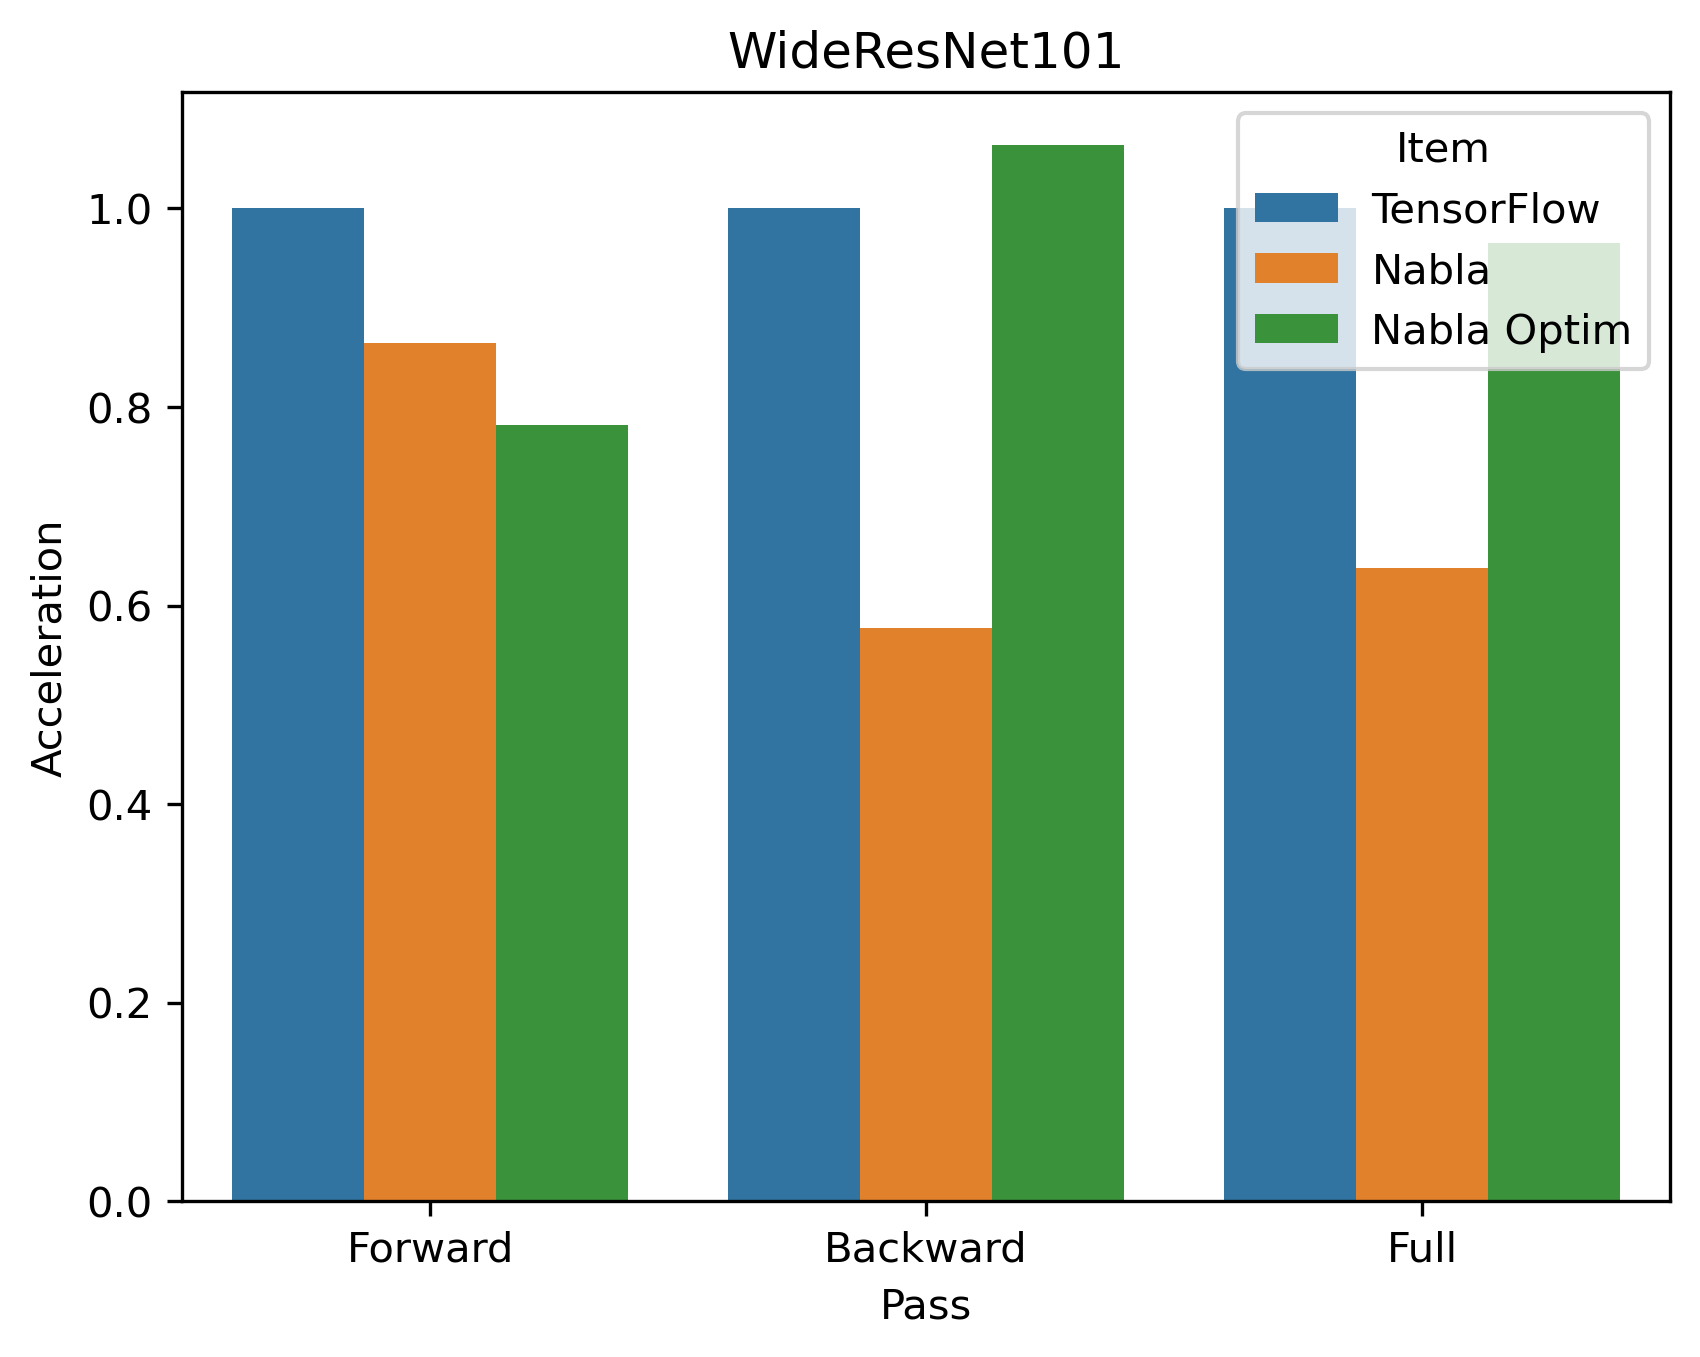

In [12]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}-acceleration.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")